# Lab 4: Data Extraction and Analysis

## Task 1: Data Extraction from retail_store_sales.csv

In [30]:
# Import necessary libraries
import pandas as pd
import numpy as np

### 1.1 Load the Dataset

In [31]:
# Load the CSV file
df = pd.read_csv('retail_store_sales.csv')

### 1.2 Display First Few Rows

In [32]:
# Display first 5 rows
df.head(5)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


### 1.3 Print Total Number of Records

In [33]:
# Print total number of records
total_records = len(df)
print(f"Total number of records: {total_records}")

Total number of records: 12575


## Task 2: Data Extraction - JSON

### 2.1 Read the JSON file

In [34]:
import json

# Read the JSON file
with open('customers.json', 'r') as file:
    json_data = json.load(file)
    
print("JSON file loaded successfully!")
print(f"Number of customers: {len(json_data)}")

JSON file loaded successfully!
Number of customers: 10


### 2.2 Convert it into a pandas DataFrame

In [35]:
# Convert JSON to DataFrame
customers_df = pd.DataFrame(json_data)
print("DataFrame created successfully!")
print(f"DataFrame shape: {customers_df.shape}")
print("\nDataFrame columns:", customers_df.columns.tolist())

DataFrame created successfully!
DataFrame shape: (10, 6)

DataFrame columns: ['customer_id', 'name', 'city', 'age', 'email', 'phone']


### 2.3 Display only customer_id, name, and city

In [36]:
# Display only customer_id, name, and city
customers_df[['customer_id', 'name', 'city']]

,customer_id,name,city
0,CUST_001,John Smith,New York
1,CUST_002,Emma Johnson,Los Angeles
2,CUST_003,Michael Brown,Chicago
3,CUST_004,Sarah Davis,Houston
4,CUST_005,David Wilson,Phoenix
5,CUST_006,Lisa Martinez,Philadelphia
6,CUST_007,James Anderson,San Antonio
7,CUST_008,Patricia Taylor,San Diego
8,CUST_009,Robert Thomas,Dallas
9,CUST_010,Jennifer Garcia,San Jose


## Task 3: Data Cleaning (Transformation)

### 3.1 Check for missing values in key columns

In [37]:
# Check missing values
print("Missing values in the dataset:")
print(df.isnull().sum())
print(f"\nTotal rows before cleaning: {len(df)}")

Missing values in the dataset:
Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

Total rows before cleaning: 12575


### 3.2 Remove rows where Quantity or Price Per Unit is missing

In [38]:
# Remove rows with missing Quantity or Price Per Unit
df_cleaned = df.dropna(subset=['Quantity', 'Price Per Unit'])
print(f"Rows after removing missing Quantity/Price: {len(df_cleaned)}")
print(f"Rows removed: {len(df) - len(df_cleaned)}")

Rows after removing missing Quantity/Price: 11362
Rows removed: 1213


### 3.3 Convert Transaction Date to datetime format

In [39]:
# Convert Transaction Date to datetime format
df_cleaned['Transaction Date'] = pd.to_datetime(df_cleaned['Transaction Date'])
print("Transaction Date converted to datetime format")
print(f"Date range: {df_cleaned['Transaction Date'].min()} to {df_cleaned['Transaction Date'].max()}")

Transaction Date converted to datetime format
Date range: 2022-01-01 00:00:00 to 2025-01-18 00:00:00


### 3.4 Verify and recalculate Total Spent = Quantity * Price Per Unit

In [40]:
# Recalculate Total Spent to ensure consistency
df_cleaned['Total Spent'] = df_cleaned['Quantity'] * df_cleaned['Price Per Unit']
print("Total Spent recalculated")
print(f"\nCleaned dataset shape: {df_cleaned.shape}")
df_cleaned.head()

Total Spent recalculated

Cleaned dataset shape: (11362, 11)


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


## Task 4: Data Filtering

### 4.1 Filter transactions where Total Spent > 200

In [41]:
# Filter high-value transactions
high_value_transactions = df_cleaned[df_cleaned['Total Spent'] > 200]
print(f"Total high-value transactions (>200): {len(high_value_transactions)}")
print(f"Percentage of total: {(len(high_value_transactions) / len(df_cleaned) * 100):.2f}%")

Total high-value transactions (>200): 2570
Percentage of total: 22.62%


### 4.2 Sort results by Total Spent in descending order

In [42]:
# Sort by Total Spent in descending order
high_value_sorted = high_value_transactions.sort_values(by='Total Spent', ascending=False)
print("Top 10 high-value transactions:")
high_value_sorted.head(10)

Top 10 high-value transactions:


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
27,TXN_1599706,CUST_14,Furniture,Item_25_FUR,41.0,10.0,410.0,Credit Card,In-store,2024-03-24,True
3036,TXN_2624160,CUST_16,Butchers,Item_25_BUT,41.0,10.0,410.0,Digital Wallet,Online,2022-06-19,True
11662,TXN_5870737,CUST_17,Computers and electric accessories,Item_25_CEA,41.0,10.0,410.0,Credit Card,Online,2024-12-24,False
3094,TXN_7177583,CUST_10,Butchers,Item_25_BUT,41.0,10.0,410.0,Cash,In-store,2024-08-31,False
9378,TXN_8837607,CUST_15,Food,Item_25_FOOD,41.0,10.0,410.0,Cash,Online,2022-11-05,NaN
9760,TXN_7254589,CUST_03,Butchers,Item_25_BUT,41.0,10.0,410.0,Cash,Online,2022-09-24,False
11608,TXN_7169895,CUST_07,Food,Item_25_FOOD,41.0,10.0,410.0,Digital Wallet,In-store,2022-05-11,NaN
2540,TXN_2208547,CUST_05,Beverages,Item_25_BEV,41.0,10.0,410.0,Credit Card,Online,2022-02-23,True
8845,TXN_4208189,CUST_23,Butchers,Item_25_BUT,41.0,10.0,410.0,Cash,In-store,2022-06-07,False
9884,TXN_8716794,CUST_13,Food,Item_25_FOOD,41.0,10.0,410.0,Cash,Online,2024-05-29,False


## Task 5: Aggregation for Analytics

### 5.1 Calculate total sales per Category

In [43]:
# Calculate total sales per Category
sales_per_category = df_cleaned.groupby('Category').agg({
    'Total Spent': 'sum',
    'Transaction ID': 'count',
    'Quantity': 'sum'
}).rename(columns={'Transaction ID': 'Transaction Count', 'Quantity': 'Total Quantity'})

sales_per_category = sales_per_category.sort_values(by='Total Spent', ascending=False)
print("Total Sales per Category:")
sales_per_category

Total Sales per Category:


,Total Spent,Transaction Count,Total Quantity
Category,,,
Butchers,197426.0,1421,7774.0
Electric household essentials,192441.5,1437,7897.0
Beverages,187978.5,1427,7974.0
Furniture,186527.0,1460,8083.0
Food,184645.0,1426,7925.0
Computers and electric accessories,180902.5,1397,7832.0
Patisserie,172330.5,1369,7515.0
Milk Products,170747.5,1425,7889.0


### 5.2 Calculate total sales per Customer ID

In [44]:
# Calculate total sales per Customer ID
sales_per_customer = df_cleaned.groupby('Customer ID').agg({
    'Total Spent': 'sum',
    'Transaction ID': 'count',
    'Quantity': 'sum'
}).rename(columns={'Transaction ID': 'Transaction Count', 'Quantity': 'Total Quantity'})

sales_per_customer = sales_per_customer.sort_values(by='Total Spent', ascending=False)
print("Top 10 Customers by Total Sales:")
sales_per_customer.head(10)

Top 10 Customers by Total Sales:


,Total Spent,Transaction Count,Total Quantity
Customer ID,,,
CUST_24,64608.0,489,2616.0
CUST_05,63855.5,497,2686.0
CUST_16,63185.5,469,2636.0
CUST_13,63015.5,491,2758.0
CUST_08,62850.5,480,2734.0
CUST_15,60749.5,478,2597.0
CUST_10,60367.5,458,2538.0
CUST_23,59738.5,450,2522.0
CUST_21,59639.0,447,2593.0


### 5.3 Summary Statistics

In [45]:
# Display summary statistics
print("="*60)
print("ANALYTICS SUMMARY")
print("="*60)
print(f"\nTotal Revenue: ${df_cleaned['Total Spent'].sum():,.2f}")
print(f"Average Transaction Value: ${df_cleaned['Total Spent'].mean():,.2f}")
print(f"Total Transactions: {len(df_cleaned):,}")
print(f"Total Customers: {df_cleaned['Customer ID'].nunique()}")
print(f"Total Product Categories: {df_cleaned['Category'].nunique()}")
print(f"\nTop Category: {sales_per_category.index[0]} (${sales_per_category['Total Spent'].iloc[0]:,.2f})")
print(f"Top Customer: {sales_per_customer.index[0]} (${sales_per_customer['Total Spent'].iloc[0]:,.2f})")
print("="*60)

ANALYTICS SUMMARY

Total Revenue: $1,472,998.50
Average Transaction Value: $129.64
Total Transactions: 11,362
Total Customers: 25
Total Product Categories: 8

Top Category: Butchers ($197,426.00)
Top Customer: CUST_24 ($64,608.00)


### 5.4 Data Visualizations

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

#### Chart 1: Total Sales by Category

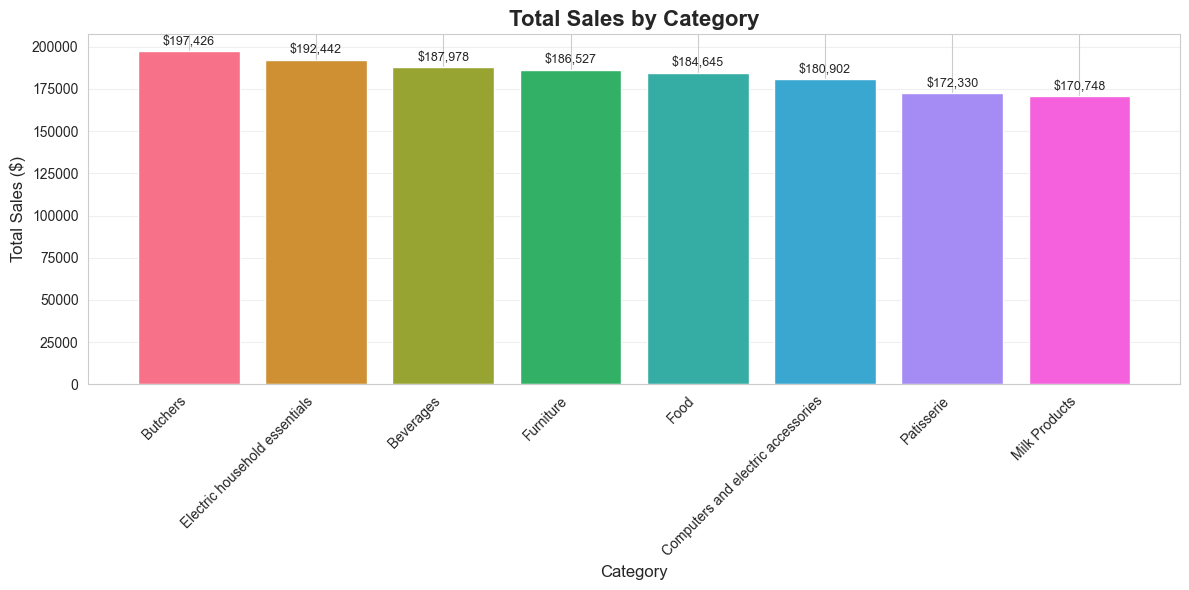

In [63]:
# Bar chart for Total Sales by Category
plt.figure(figsize=(12, 6))
colors = sns.color_palette("husl", len(sales_per_category))
plt.bar(sales_per_category.index, sales_per_category['Total Spent'], color=colors)
plt.title('Total Sales by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(sales_per_category['Total Spent']):
    plt.text(i, v + 2000, f'${v:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

#### Chart 2: Top 10 Customers by Total Sales

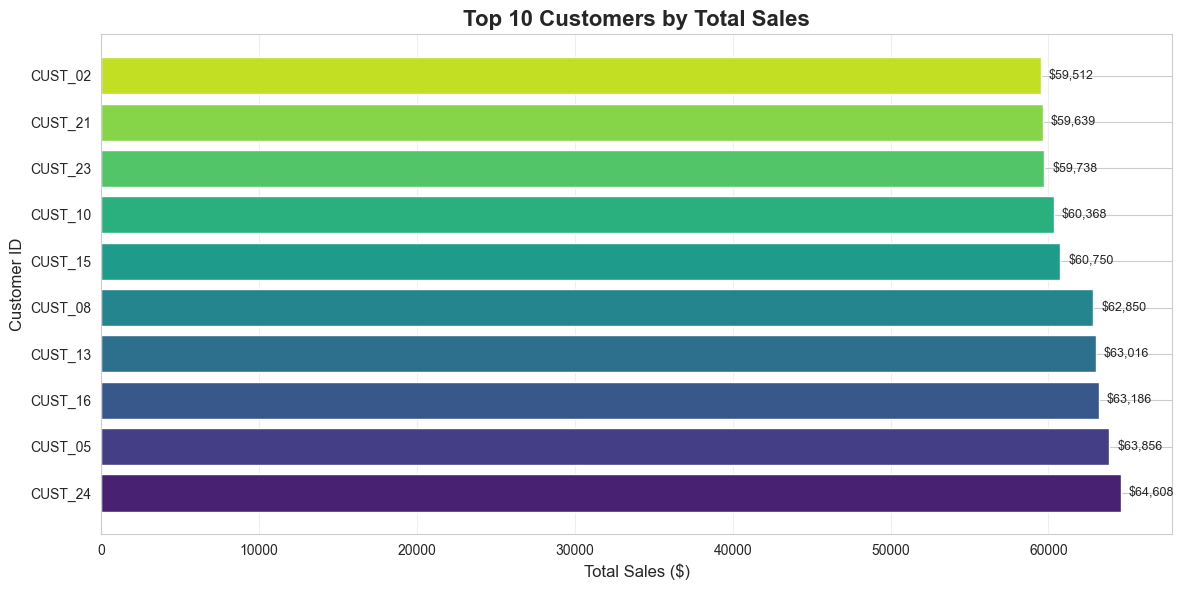

In [64]:
# Horizontal bar chart for Top 10 Customers
plt.figure(figsize=(12, 6))
top10_customers = sales_per_customer.head(10)
colors = sns.color_palette("viridis", 10)
plt.barh(top10_customers.index, top10_customers['Total Spent'], color=colors)
plt.title('Top 10 Customers by Total Sales', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Customer ID', fontsize=12)
plt.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(top10_customers['Total Spent']):
    plt.text(v + 500, i, f'${v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

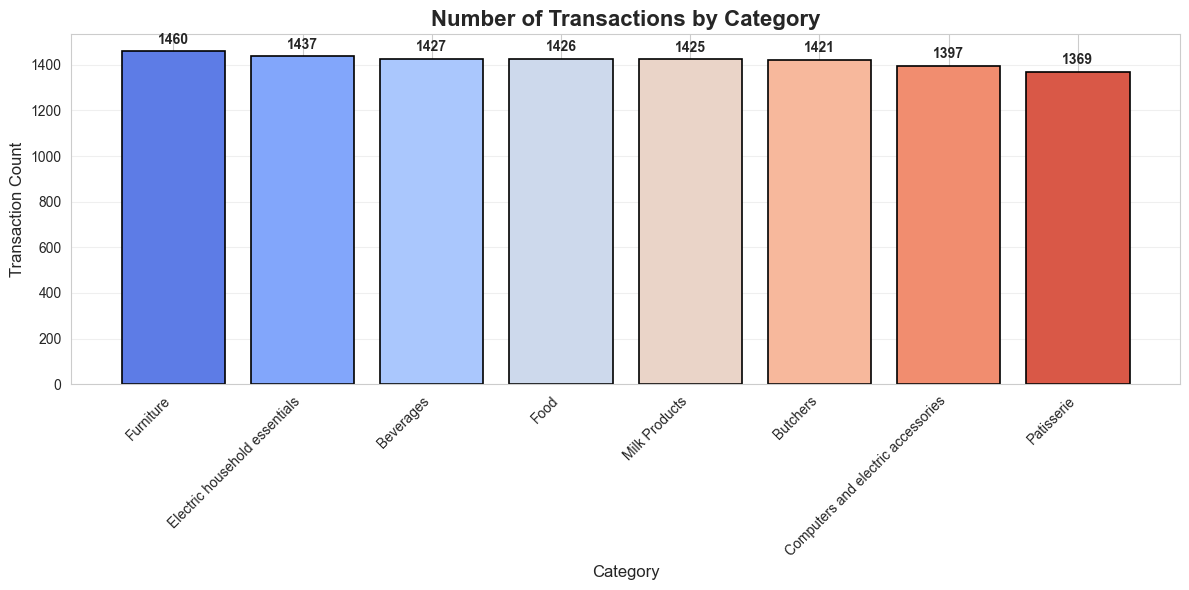

In [65]:
# Bar chart showing number of transactions per category
plt.figure(figsize=(12, 6))
transaction_counts = sales_per_category['Transaction Count'].sort_values(ascending=False)
colors = sns.color_palette("coolwarm", len(transaction_counts))
plt.bar(range(len(transaction_counts)), transaction_counts, color=colors, edgecolor='black', linewidth=1.2)
plt.title('Number of Transactions by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Transaction Count', fontsize=12)
plt.xticks(range(len(transaction_counts)), transaction_counts.index, rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(transaction_counts):
    plt.text(i, v + 20, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

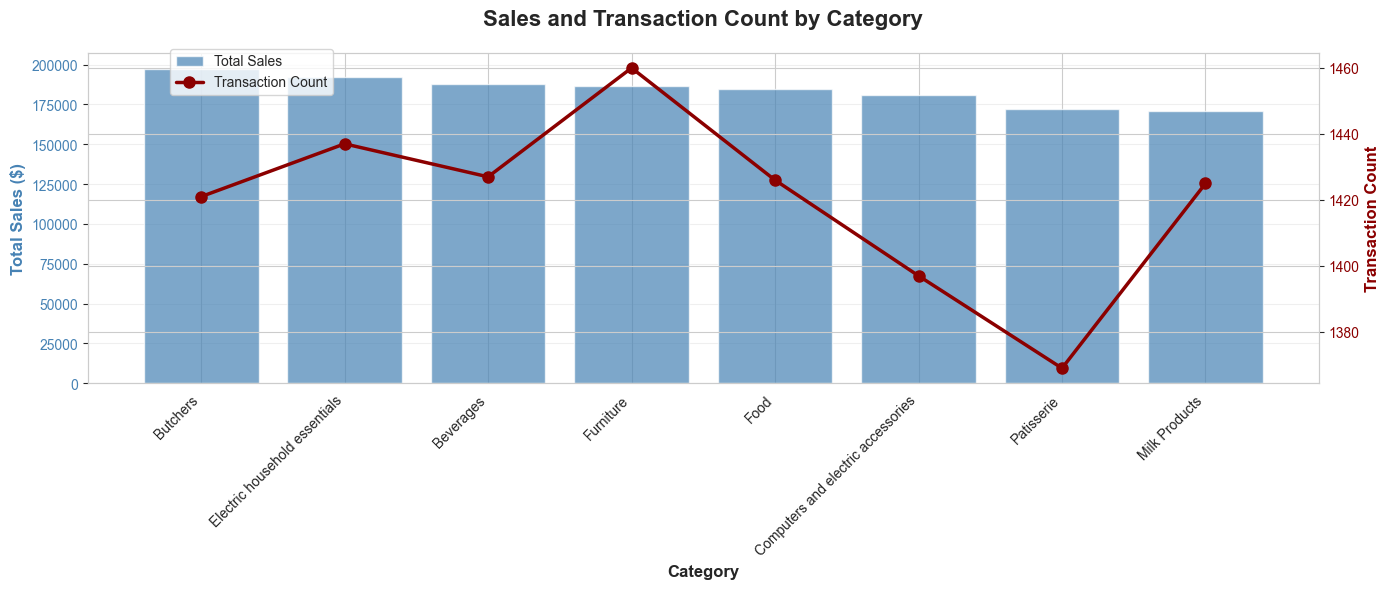

In [66]:
# Dual-axis chart: Total Sales (bars) and Transaction Count (line)
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart for Total Sales
x_pos = range(len(sales_per_category))
bars = ax1.bar(x_pos, sales_per_category['Total Spent'], color='steelblue', alpha=0.7, label='Total Sales')
ax1.set_xlabel('Category', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Sales ($)', fontsize=12, fontweight='bold', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(sales_per_category.index, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Line chart for Transaction Count on secondary axis
ax2 = ax1.twinx()
line = ax2.plot(x_pos, sales_per_category['Transaction Count'], color='darkred', marker='o', 
                linewidth=2.5, markersize=8, label='Transaction Count')
ax2.set_ylabel('Transaction Count', fontsize=12, fontweight='bold', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

# Title and legends
plt.title('Sales and Transaction Count by Category', fontsize=16, fontweight='bold', pad=20)
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.92), fontsize=10)
fig.tight_layout()
plt.show()

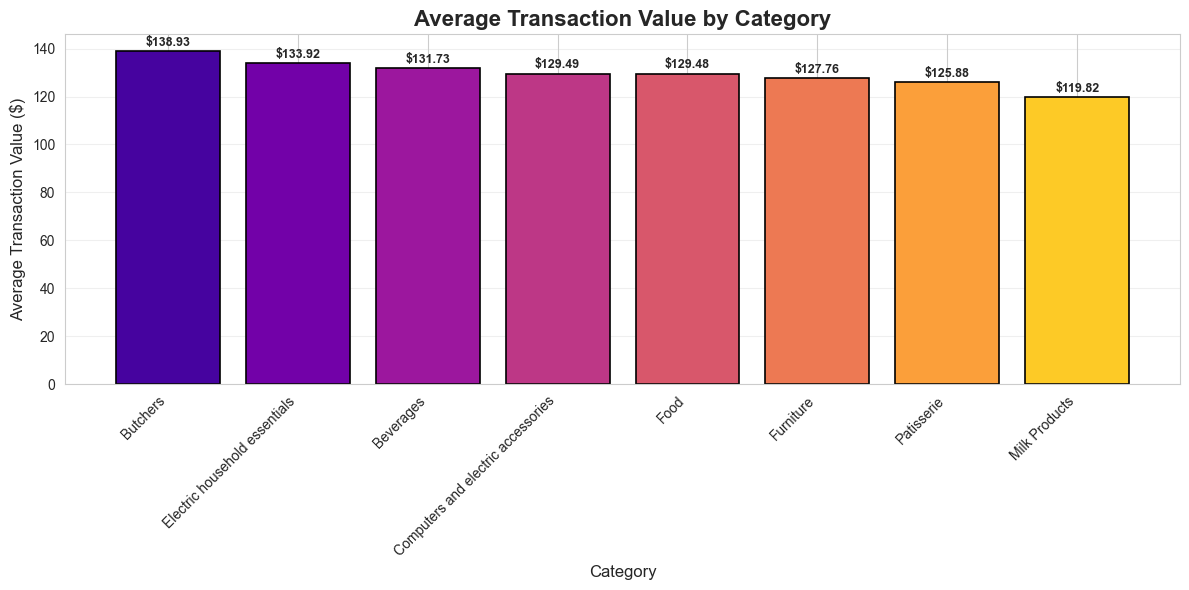

In [68]:
# Bar chart showing average transaction value per category
plt.figure(figsize=(12, 6))
avg_value = (sales_per_category['Total Spent'] / sales_per_category['Transaction Count']).sort_values(ascending=False)
colors = sns.color_palette("plasma", len(avg_value))
plt.bar(range(len(avg_value)), avg_value, color=colors, edgecolor='black', linewidth=1.2)
plt.title('Average Transaction Value by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Average Transaction Value ($)', fontsize=12)
plt.xticks(range(len(avg_value)), avg_value.index, rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(avg_value):
    plt.text(i, v + 1, f'${v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Task 6: ETL Pipeline - Modular Design

### 6.1 Define ETL Functions

In [46]:
def extract_data(file_path):
    """
    Extract: Reads CSV file
    """
    print(f"Extracting data from {file_path}...")
    data = pd.read_csv(file_path)
    print(f"✓ Extracted {len(data)} rows")
    return data

def transform_data(data):
    """
    Transform: Cleans and adds derived columns
    """
    print("Transforming data...")
    
    # Remove rows with missing Quantity or Price Per Unit
    data_clean = data.dropna(subset=['Quantity', 'Price Per Unit']).copy()
    print(f"✓ Removed {len(data) - len(data_clean)} rows with missing values")
    
    # Convert Transaction Date to datetime
    data_clean['Transaction Date'] = pd.to_datetime(data_clean['Transaction Date'])
    print("✓ Converted Transaction Date to datetime")
    
    # Recalculate Total Spent
    data_clean['Total Spent'] = data_clean['Quantity'] * data_clean['Price Per Unit']
    print("✓ Recalculated Total Spent")
    
    # Add derived columns
    data_clean['Year'] = data_clean['Transaction Date'].dt.year
    data_clean['Month'] = data_clean['Transaction Date'].dt.month
    data_clean['Day_of_Week'] = data_clean['Transaction Date'].dt.day_name()
    print("✓ Added derived columns (Year, Month, Day_of_Week)")
    
    print(f"✓ Transformation complete. Final shape: {data_clean.shape}")
    return data_clean

def load_data(data, output_file):
    """
    Load: Saves processed data to a new CSV
    """
    print(f"Loading data to {output_file}...")
    data.to_csv(output_file, index=False)
    print(f"✓ Data saved successfully to {output_file}")
    return output_file

### 6.2 Execute ETL Pipeline

In [47]:
# Execute ETL Pipeline
print("="*60)
print("STARTING ETL PIPELINE")
print("="*60)

# Extract
raw_data = extract_data('retail_store_sales.csv')

# Transform
transformed_data = transform_data(raw_data)

# Load
output_file = load_data(transformed_data, 'processed_sales.csv')

print("="*60)
print("ETL PIPELINE COMPLETED SUCCESSFULLY!")
print("="*60)

STARTING ETL PIPELINE
Extracting data from retail_store_sales.csv...
✓ Extracted 12575 rows
Transforming data...
✓ Removed 1213 rows with missing values
✓ Converted Transaction Date to datetime
✓ Recalculated Total Spent
✓ Added derived columns (Year, Month, Day_of_Week)
✓ Transformation complete. Final shape: (11362, 14)
Loading data to processed_sales.csv...
✓ Data saved successfully to processed_sales.csv
ETL PIPELINE COMPLETED SUCCESSFULLY!


## Task 7: Loading Data into SQLite (Load Phase)

### 7.1 Import SQLite library

In [48]:
import sqlite3

### 7.2 Create SQLite database and table

In [49]:
# Create SQLite database
conn = sqlite3.connect('sales.db')
cursor = conn.cursor()

# Create table processed_sales
create_table_query = '''
CREATE TABLE IF NOT EXISTS processed_sales (
    transaction_id TEXT PRIMARY KEY,
    customer_id TEXT,
    category TEXT,
    item TEXT,
    price_per_unit REAL,
    quantity REAL,
    total_spent REAL,
    payment_method TEXT,
    location TEXT,
    transaction_date TEXT,
    discount_applied TEXT,
    year INTEGER,
    month INTEGER,
    day_of_week TEXT
)
'''

cursor.execute(create_table_query)
conn.commit()

print("✓ Database 'sales.db' created successfully")
print("✓ Table 'processed_sales' created successfully")

✓ Database 'sales.db' created successfully
✓ Table 'processed_sales' created successfully


### 7.3 Insert transformed sales data into the table

In [50]:
# Insert transformed data into SQLite table
print("Inserting data into SQLite database...")

# Use pandas to_sql for efficient insertion
transformed_data.columns = transformed_data.columns.str.lower().str.replace(' ', '_')
transformed_data.to_sql('processed_sales', conn, if_exists='replace', index=False)

print(f"✓ Successfully inserted {len(transformed_data)} rows into 'processed_sales' table")

# Verify the data
cursor.execute("SELECT COUNT(*) FROM processed_sales")
count = cursor.fetchone()[0]
print(f"✓ Verified: {count} records in database")

Inserting data into SQLite database...
✓ Successfully inserted 11362 rows into 'processed_sales' table
✓ Verified: 11362 records in database


### 7.4 Query the database to verify data

In [51]:
# Query to fetch sample data
query = "SELECT * FROM processed_sales LIMIT 10"
sample_data = pd.read_sql_query(query, conn)

print("Sample data from SQLite database:")
print(sample_data)

# Close the connection
conn.close()
print("\n✓ Database connection closed")

Sample data from SQLite database:
  transaction_id customer_id       category          item  price_per_unit  \
0    TXN_6867343     CUST_09     Patisserie   Item_10_PAT            18.5   
1    TXN_3731986     CUST_22  Milk Products  Item_17_MILK            29.0   
2    TXN_9303719     CUST_02       Butchers   Item_12_BUT            21.5   
3    TXN_9458126     CUST_06      Beverages   Item_16_BEV            27.5   
4    TXN_4575373     CUST_05           Food   Item_6_FOOD            12.5   
5    TXN_3652209     CUST_07           Food   Item_1_FOOD             5.0   
6    TXN_9728486     CUST_23      Furniture   Item_16_FUR            27.5   
7    TXN_2722661     CUST_25       Butchers   Item_22_BUT            36.5   
8    TXN_8776416     CUST_22       Butchers    Item_3_BUT             8.0   
9    TXN_5874772     CUST_23           Food   Item_2_FOOD             6.5   

   quantity  total_spent  payment_method  location     transaction_date  \
0      10.0        185.0  Digital Wallet   

## Task 8: Data Validation

### 8.1 Fetch total number of records from the database

In [52]:
# Reconnect to database for validation
conn = sqlite3.connect('sales.db')
cursor = conn.cursor()

# Fetch total number of records from the table
cursor.execute("SELECT COUNT(*) FROM processed_sales")
db_record_count = cursor.fetchone()[0]

print("="*60)
print("DATA VALIDATION")
print("="*60)
print(f"Total records in SQLite database: {db_record_count}")

DATA VALIDATION
Total records in SQLite database: 11362


### 8.2 Verify it matches the transformed DataFrame row count

In [53]:
# Get the row count from transformed DataFrame
df_record_count = len(transformed_data)

print(f"Total records in transformed DataFrame: {df_record_count}")
print("-"*60)

# Verify if they match
if db_record_count == df_record_count:
    print("✓ VALIDATION SUCCESSFUL!")
    print(f"  Database record count ({db_record_count}) matches DataFrame row count ({df_record_count})")
else:
    print("✗ VALIDATION FAILED!")
    print(f"  Database has {db_record_count} records but DataFrame has {df_record_count} rows")
    print(f"  Difference: {abs(db_record_count - df_record_count)} records")

print("="*60)

# Close connection
conn.close()

Total records in transformed DataFrame: 11362
------------------------------------------------------------
✓ VALIDATION SUCCESSFUL!
  Database record count (11362) matches DataFrame row count (11362)


## Task 9: Logging ETL Steps

### 9.1 Enhanced ETL Functions with Logging

In [54]:
from datetime import datetime

def extract_data_logged(file_path):
    """
    Extract: Reads CSV file with logging
    """
    start_time = datetime.now()
    print(f"[{start_time.strftime('%Y-%m-%d %H:%M:%S')}] EXTRACT - Starting data extraction...")
    
    data = pd.read_csv(file_path)
    
    end_time = datetime.now()
    duration = (end_time - start_time).total_seconds()
    print(f"[{end_time.strftime('%Y-%m-%d %H:%M:%S')}] EXTRACT - Completed")
    print(f"  ✓ Extracted {len(data)} rows from {file_path}")
    print(f"  ⏱ Duration: {duration:.2f} seconds")
    
    return data

def transform_data_logged(data):
    """
    Transform: Cleans and adds derived columns with logging
    """
    start_time = datetime.now()
    print(f"\n[{start_time.strftime('%Y-%m-%d %H:%M:%S')}] TRANSFORM - Starting data transformation...")
    
    # Remove rows with missing values
    data_clean = data.dropna(subset=['Quantity', 'Price Per Unit']).copy()
    print(f"  ✓ Removed {len(data) - len(data_clean)} rows with missing values")
    
    # Convert Transaction Date to datetime
    data_clean['Transaction Date'] = pd.to_datetime(data_clean['Transaction Date'])
    print("  ✓ Converted Transaction Date to datetime")
    
    # Recalculate Total Spent
    data_clean['Total Spent'] = data_clean['Quantity'] * data_clean['Price Per Unit']
    print("  ✓ Recalculated Total Spent")
    
    # Add derived columns
    data_clean['Year'] = data_clean['Transaction Date'].dt.year
    data_clean['Month'] = data_clean['Transaction Date'].dt.month
    data_clean['Day_of_Week'] = data_clean['Transaction Date'].dt.day_name()
    print("  ✓ Added derived columns (Year, Month, Day_of_Week)")
    
    end_time = datetime.now()
    duration = (end_time - start_time).total_seconds()
    print(f"[{end_time.strftime('%Y-%m-%d %H:%M:%S')}] TRANSFORM - Completed")
    print(f"  ✓ Final shape: {data_clean.shape}")
    print(f"  ⏱ Duration: {duration:.2f} seconds")
    
    return data_clean

def load_data_logged(data, output_file):
    """
    Load: Saves processed data to CSV with logging
    """
    start_time = datetime.now()
    print(f"\n[{start_time.strftime('%Y-%m-%d %H:%M:%S')}] LOAD - Starting data loading...")
    
    data.to_csv(output_file, index=False)
    
    end_time = datetime.now()
    duration = (end_time - start_time).total_seconds()
    print(f"[{end_time.strftime('%Y-%m-%d %H:%M:%S')}] LOAD - Completed")
    print(f"  ✓ Saved {len(data)} rows to {output_file}")
    print(f"  ⏱ Duration: {duration:.2f} seconds")
    
    return output_file

### 9.2 Execute Enhanced ETL Pipeline with Logging

In [55]:
# Record pipeline start time
pipeline_start = datetime.now()
print("="*70)
print("ENHANCED ETL PIPELINE WITH LOGGING")
print("="*70)
print(f"Pipeline started at: {pipeline_start.strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

# Execute ETL Pipeline with Logging
# Extract
raw_data_logged = extract_data_logged('retail_store_sales.csv')

# Transform
transformed_data_logged = transform_data_logged(raw_data_logged)

# Load
output_file_logged = load_data_logged(transformed_data_logged, 'processed_sales_logged.csv')

# Record pipeline end time
pipeline_end = datetime.now()
total_duration = (pipeline_end - pipeline_start).total_seconds()

print("\n" + "="*70)
print("ETL PIPELINE SUMMARY")
print("="*70)
print(f"Start Time:      {pipeline_start.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"End Time:        {pipeline_end.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total Duration:  {total_duration:.2f} seconds ({total_duration/60:.2f} minutes)")
print(f"Records Processed: {len(transformed_data_logged):,}")
print("="*70)
print("✓ PIPELINE COMPLETED SUCCESSFULLY!")
print("="*70)

ENHANCED ETL PIPELINE WITH LOGGING
Pipeline started at: 2026-02-08 15:31:57
[2026-02-08 15:31:57] EXTRACT - Starting data extraction...
[2026-02-08 15:31:57] EXTRACT - Completed
  ✓ Extracted 12575 rows from retail_store_sales.csv
  ⏱ Duration: 0.08 seconds

[2026-02-08 15:31:57] TRANSFORM - Starting data transformation...
  ✓ Removed 1213 rows with missing values
  ✓ Converted Transaction Date to datetime


  ✓ Recalculated Total Spent
  ✓ Added derived columns (Year, Month, Day_of_Week)
[2026-02-08 15:31:57] TRANSFORM - Completed
  ✓ Final shape: (11362, 14)
  ⏱ Duration: 0.06 seconds

[2026-02-08 15:31:57] LOAD - Starting data loading...
[2026-02-08 15:31:57] LOAD - Completed
  ✓ Saved 11362 rows to processed_sales_logged.csv
  ⏱ Duration: 0.27 seconds

ETL PIPELINE SUMMARY
Start Time:      2026-02-08 15:31:57
End Time:        2026-02-08 15:31:57
Total Duration:  0.42 seconds (0.01 minutes)
Records Processed: 11,362
✓ PIPELINE COMPLETED SUCCESSFULLY!


## Task 10: Applied Data Engineering Task

### 10.1 Automatically read all CSV files from raw_data folder

In [56]:
import os
import glob

# Define the raw_data folder path
raw_data_folder = 'raw_data'

# Get all CSV files from the folder
csv_files = glob.glob(os.path.join(raw_data_folder, '*.csv'))

print("="*70)
print("READING CSV FILES FROM raw_data/")
print("="*70)
print(f"Found {len(csv_files)} CSV file(s):\n")

# Read all CSV files into a list of DataFrames
dataframes = []
for file in csv_files:
    filename = os.path.basename(file)
    print(f"Reading: {filename}")
    df_temp = pd.read_csv(file)
    print(f"  ✓ Shape: {df_temp.shape}")
    print(f"  ✓ Columns: {list(df_temp.columns)[:5]}..." if len(df_temp.columns) > 5 else f"  ✓ Columns: {list(df_temp.columns)}")
    dataframes.append(df_temp)
    print()

print(f"Total DataFrames loaded: {len(dataframes)}")
print("="*70)

READING CSV FILES FROM raw_data/
Found 2 CSV file(s):

Reading: epl2020.csv
  ✓ Shape: (576, 45)
  ✓ Columns: ['Unnamed: 0', 'h_a', 'xG', 'xGA', 'npxG']...

Reading: players_1920.csv
  ✓ Shape: (22502, 35)
  ✓ Columns: ['Unnamed: 0', 'assists', 'bonus', 'bps', 'clean_sheets']...

Total DataFrames loaded: 2


### 10.2 Merge into a single DataFrame

In [57]:
print("\n" + "="*70)
print("MERGING DATAFRAMES")
print("="*70)

# Add source file identifier to each DataFrame
for i, (df_temp, file) in enumerate(zip(dataframes, csv_files)):
    filename = os.path.basename(file)
    df_temp['source_file'] = filename
    print(f"Added 'source_file' column to {filename}")

# Merge all DataFrames into a single DataFrame
# Using concat to combine all DataFrames (will create NaN for non-matching columns)
merged_df = pd.concat(dataframes, ignore_index=True, sort=False)

print(f"\n✓ Merged DataFrame created")
print(f"  Total rows: {len(merged_df):,}")
print(f"  Total columns: {len(merged_df.columns)}")
print("="*70)

# Display basic info
print("\nMerged DataFrame Info:")
print(f"Shape: {merged_df.shape}")
print(f"\nFirst few rows:")
merged_df.head()


MERGING DATAFRAMES
Added 'source_file' column to epl2020.csv
Added 'source_file' column to players_1920.csv

✓ Merged DataFrame created
  Total rows: 23,078
  Total columns: 79

Merged DataFrame Info:
Shape: (23078, 79)

First few rows:


,Unnamed: 0,h_a,xG,xGA,npxG,npxGA,deep,deep_allowed,scored,missed,...,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,full,team,ppm
0,1,h,2.234560,0.842407,2.234560,0.842407,11.0,5.0,4.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,a,0.842407,2.234560,0.842407,2.234560,5.0,11.0,1.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,a,3.183770,1.200300,2.422640,1.200300,9.0,1.0,5.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,h,1.200300,3.183770,1.200300,2.422640,1.0,9.0,0.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,h,1.340990,1.598640,1.340990,1.598640,4.0,6.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 10.3 Apply cleaning and transformation

In [58]:
print("\n" + "="*70)
print("CLEANING AND TRANSFORMATION")
print("="*70)

# Make a copy for transformation
final_df = merged_df.copy()

# 1. Check missing values
print("\n1. Missing values before cleaning:")
missing_before = final_df.isnull().sum().sum()
print(f"   Total missing values: {missing_before:,}")

# 2. Remove columns with more than 50% missing values
threshold = 0.5
cols_to_drop = []
for col in final_df.columns:
    missing_pct = final_df[col].isnull().sum() / len(final_df)
    if missing_pct > threshold:
        cols_to_drop.append(col)

if cols_to_drop:
    final_df = final_df.drop(columns=cols_to_drop)
    print(f"\n2. Dropped {len(cols_to_drop)} columns with >50% missing values")
else:
    print("\n2. No columns needed to be dropped")

# 3. Fill numeric columns with median, categorical with 'Unknown'
print("\n3. Filling missing values:")
for col in final_df.columns:
    if final_df[col].dtype in ['float64', 'int64']:
        if final_df[col].isnull().any():
            median_val = final_df[col].median()
            final_df[col].fillna(median_val, inplace=True)
            print(f"   ✓ Filled {col} (numeric) with median")
    elif final_df[col].isnull().any():
        final_df[col].fillna('Unknown', inplace=True)
        print(f"   ✓ Filled {col} (categorical) with 'Unknown'")

# 4. Remove duplicate rows
duplicates_before = final_df.duplicated().sum()
if duplicates_before > 0:
    final_df = final_df.drop_duplicates()
    print(f"\n4. Removed {duplicates_before} duplicate rows")
else:
    print("\n4. No duplicate rows found")

# 5. Add derived columns
final_df['record_id'] = range(1, len(final_df) + 1)
final_df['processing_date'] = datetime.now().strftime('%Y-%m-%d')
print("\n5. Added derived columns:")
print("   ✓ record_id")
print("   ✓ processing_date")

# Final stats
print("\n" + "="*70)
print("TRANSFORMATION SUMMARY")
print("="*70)
print(f"Original shape:     {merged_df.shape}")
print(f"Final shape:        {final_df.shape}")
print(f"Rows retained:      {len(final_df):,} ({(len(final_df)/len(merged_df)*100):.2f}%)")
print(f"Missing values now: {final_df.isnull().sum().sum()}")
print("="*70)


CLEANING AND TRANSFORMATION

1. Missing values before cleaning:
   Total missing values: 986,594

2. Dropped 43 columns with >50% missing values

3. Filling missing values:
   ✓ Filled assists (numeric) with median
   ✓ Filled bonus (numeric) with median
   ✓ Filled bps (numeric) with median
   ✓ Filled clean_sheets (numeric) with median
   ✓ Filled creativity (numeric) with median
   ✓ Filled element (numeric) with median
   ✓ Filled fixture (numeric) with median
   ✓ Filled goals_conceded (numeric) with median
   ✓ Filled goals_scored (numeric) with median
   ✓ Filled ict_index (numeric) with median
   ✓ Filled influence (numeric) with median
   ✓ Filled kickoff_time (categorical) with 'Unknown'
   ✓ Filled minutes (numeric) with median
   ✓ Filled opponent_team (categorical) with 'Unknown'
   ✓ Filled own_goals (numeric) with median
   ✓ Filled penalties_missed (numeric) with median
   ✓ Filled penalties_saved (numeric) with median
   ✓ Filled red_cards (numeric) with median
   ✓ F

C:\Users\mausa\AppData\Local\Temp\ipykernel_9896\2665415436.py:33: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  final_df[col].fillna(median_val, inplace=True)
C:\Users\mausa\AppData\Local\Temp\ipykernel_9896\2665415436.py:33: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment u

### 10.4 Save final output as final_dataset.csv

In [60]:
# Save the final dataset
output_filename = 'final_dataset.csv'
final_df.to_csv(output_filename, index=False)

print("\n" + "="*70)
print("SAVE FINAL DATASET")
print("="*70)
print(f"✓ Final dataset saved as: {output_filename}")
print(f"  Rows: {len(final_df):,}")
print(f"  Columns: {len(final_df.columns)}")
print(f"  File size: {os.path.getsize(output_filename) / (1024*1024):.2f} MB")
print("="*70)




SAVE FINAL DATASET
✓ Final dataset saved as: final_dataset.csv
  Rows: 23,078
  Columns: 38
  File size: 5.16 MB
